# Bias in Bios: erasing gender with `jevu`

Runs the package on a **real** fairness dataset
([Bias in Bios](https://huggingface.co/datasets/LabHC/bias_in_bios): biographies labeled with
`occupation` and `gender`). Everything goes through **`ConceptScrubber`** — it labels the concept
with JEV and erases it. We:

1. bring our own **texts** and **embeddings** (`text-embedding-3-small`),
2. score the concept *"is this about a woman?"* with `ConceptScrubber.concept_scores` (JEV, zero-shot),
3. erase it with `ConceptScrubber` (LEACE and INLP),
4. audit against the **true** labels — gender recoverability, occupation accuracy, TPR gap,
5. **plot the embedding space before vs. after erasure**.

All API responses are cached in `examples/.jev_debias_cache`, so this notebook runs offline from
any working directory (JupyterLab, VS Code, or nbconvert). Needs `pip install "jevu[examples]"`.

In [1]:
import os, sys, json, hashlib
from pathlib import Path
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')
for _noisy in ('httpx', 'httpcore', 'openai', 'openai._base_client'):
    logging.getLogger(_noisy).setLevel(logging.WARNING)   # silence OpenAI/OpenRouter request logs

# Locate the repo (and its cache) regardless of the kernel's working directory,
# so this runs the same from JupyterLab, VS Code, or nbconvert.
def _repo_root(start):
    for q in [Path(start).resolve(), *Path(start).resolve().parents]:
        if (q / 'pyproject.toml').exists() and (q / 'src' / 'jevu').exists():
            return q
    return Path(start).resolve()
ROOT = _repo_root(os.getcwd())
if str(ROOT / 'src') not in sys.path: sys.path.insert(0, str(ROOT / 'src'))
from jevu import ConceptScrubber, concept_auc, tpr_gap

# load API keys from the repo .env (only needed on a cache miss)
_envf = ROOT / '.env'
if _envf.exists():
    for _line in _envf.read_text().splitlines():
        _line = _line.strip()
        if _line and not _line.startswith('#') and '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k.strip(), _v.strip().strip('\'"'))

USE_CACHE = True    # cached run (offline). Set False to force live API calls each time.
CACHE = (ROOT / 'examples' / '.jev_debias_cache') if USE_CACHE else None
if CACHE: CACHE.mkdir(parents=True, exist_ok=True)
SEED = 2026
DATASET, CONFIG, SPLIT = 'LabHC/bias_in_bios', 'default', 'test'
N = 900
DENSE_MODEL = 'text-embedding-3-small'
HF_ROWS = 'https://datasets-server.huggingface.co/rows'
CONCEPT = 'Occupation'  # any discriminative yes/no concept
def digest(x): return hashlib.sha256(json.dumps(x, sort_keys=True, ensure_ascii=False).encode()).hexdigest()
def save_json(p, x): p.write_text(json.dumps(x, ensure_ascii=False))
print('jevu example | caching:', bool(CACHE))

jevu example | caching: True


## 1. Bring your data: texts + embeddings

Data prep is your responsibility (the package takes embeddings as input). `httpx`/`openai` are
imported lazily, so a cache-only run needs neither.

In [2]:
def hf_page(offset, length=100):
    path = (CACHE/f'bios_{SPLIT}_{offset}_{length}.json') if CACHE else None
    if path and path.exists(): return json.loads(path.read_text())
    import httpx
    params = {'dataset': DATASET, 'config': CONFIG, 'split': SPLIT, 'offset': int(offset), 'length': int(length)}
    r = httpx.get(HF_ROWS, params=params, timeout=60); r.raise_for_status()
    data = r.json()
    if path: save_json(path, data)
    return data

def load_bios(n, seed):
    path = (CACHE/f'bios_sample_{n}_{seed}.json') if CACHE else None
    if path and path.exists(): return json.loads(path.read_text())['rows']
    total = hf_page(0, 1)['num_rows_total']
    rng = np.random.default_rng(seed); offsets = list(rng.permutation(np.arange(0, total, 100)))
    rows = []
    for off in offsets:
        for item in hf_page(int(off), 100)['rows']:
            r = item['row']; t = str(r['hard_text'] or '').strip()
            if t: rows.append({'text': t[:700], 'prof': int(r['profession']), 'gender': int(r['gender'])})
        if len(rows) >= n: break
    rng.shuffle(rows); rows = rows[:n]
    if path: save_json(path, {'rows': rows})
    return rows

def embed_dense(texts):
    path = (CACHE/f'dense_{digest({"m": DENSE_MODEL, "t": texts})}.json') if CACHE else None
    if path and path.exists(): return np.asarray(json.loads(path.read_text()), dtype=float)
    from openai import OpenAI
    client = OpenAI(timeout=90); vecs = []
    for s in range(0, len(texts), 200):
        vecs.extend(x.embedding for x in client.embeddings.create(model=DENSE_MODEL, input=texts[s:s+200]).data)
    v = np.asarray(vecs, dtype=float)
    if path: save_json(path, v.tolist())
    return v

rows = load_bios(N, SEED)
texts = [r['text'] for r in rows]
prof = np.array([r['prof'] for r in rows])            # occupation label -> KEEP
gender_raw = np.array([r['gender'] for r in rows])    # gender label     -> ERASE
X = normalize(embed_dense(texts))                     # off-the-shelf embeddings (frozen)
print(len(texts), 'bios |', len(np.unique(prof)), 'professions | embeddings', X.shape)

900 bios | 28 professions | embeddings (900, 1536)


## 2. Score the concept with `ConceptScrubber.concept_scores`

One plain-English question → a calibrated 0–1 score per text (JEV, zero-shot). We detect the "female"
polarity from the scores (not hardcoded) and check agreement with the dataset's true labels.

In [3]:
EXPAND = True   # True -> LLM expands a terse concept into sub-questions (needs keys; slower)
scorer = ConceptScrubber(concept=CONCEPT, expand=EXPAND, n_questions=2)
g = scorer.concept_scores(texts)                   # (n,) or (n, k) if expanded
concept_lbl = (g >= 0.5).astype(int)               # binary concept label(s): erase + audit targets
concept_1d = concept_lbl if concept_lbl.ndim == 1 else (g.mean(axis=1) >= 0.5).astype(int)
pos = int(concept_1d.sum())
print(f'concept present in {pos}/{len(texts)} texts (mean JEV score {float(np.mean(g)):.2f})')
if pos == 0 or pos == len(texts):
    print('WARNING: concept is non-discriminative (nearly all same answer) -> nothing to erase; '
          'use a more specific question or expand=True.')

INFO httpx2: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO jevu.concepts: expanded concept 'Occupation' into 2 questions: ['Does the text describe someone working as a healthcare professional?', 'Does the text describe someone in a creative or artistic occupation?']


INFO jevu.concepts: scoring 900 texts x 2 sub-concepts = 1800 cells (0 cached, 1800 to fetch)


JEV x2: Occupation:   0%|          | 0/1800 [00:00<?, ?it/s]

concept present in 229/900 texts (mean JEV score 0.30)


## 3. Erase with `ConceptScrubber`, then audit against true labels

We fit each scrubber on the **training** split with JEV's labels, apply it to all embeddings, and
measure on held-out data with the **true** labels.

In [4]:
idx = np.arange(len(texts))
strat = concept_1d if 0 < int(concept_1d.sum()) < len(texts) else None
tr, te = train_test_split(idx, test_size=0.3, random_state=SEED, stratify=strat)

def occ_metrics(Xtr_, Xte_):
    clf = LogisticRegression(max_iter=3000).fit(Xtr_, prof[tr]); pred = clf.predict(Xte_)
    return accuracy_score(prof[te], pred), tpr_gap(prof[te], pred, concept_1d[te], 10)

results = []
acc, gap = occ_metrics(X[tr], X[te])
results.append(('raw (no erasure)', concept_auc(X, concept_1d), acc, gap))
scrubbed = {}
for name, method in [('LEACE', 'leace'), ('INLP', 'inlp')]:
    scr = ConceptScrubber(method=method)
    scr.fit(embeddings=X[tr], labels=concept_lbl[tr])   # erase the CONCEPT you chose
    Xd = scr.transform(embeddings=X); scrubbed[name] = Xd
    acc, gap = occ_metrics(Xd[tr], Xd[te])
    results.append((name, concept_auc(Xd, concept_1d), acc, gap))

print(f"{'method':<18}{'concept AUC':>13}{'occupation acc':>16}{'TPR gap':>10}")
for n, a, ac, gp in results:
    print(f"{n:<18}{a:>13.3f}{ac:>16.3f}{gp:>10.3f}")

INFO jevu.erasers: LEACE erased concept (d=1536, k=2)


INFO jevu.erasers: INLP erased 2 concept column(s) in 3 projection round(s)


method              concept AUC  occupation acc   TPR gap
raw (no erasure)          0.928           0.633       nan
LEACE                     0.544           0.470       nan
INLP                      0.518           0.444       nan


## 4. Plot the space before vs. after erasure

**Top row** projects every embedding onto the *gender direction* (a probe's normal): women vs. men
separate cleanly **before**, and collapse onto each other **after**. **Bottom row** is a 2-D PCA
(same axes before/after) coloured by the top occupations — those clusters are largely preserved.

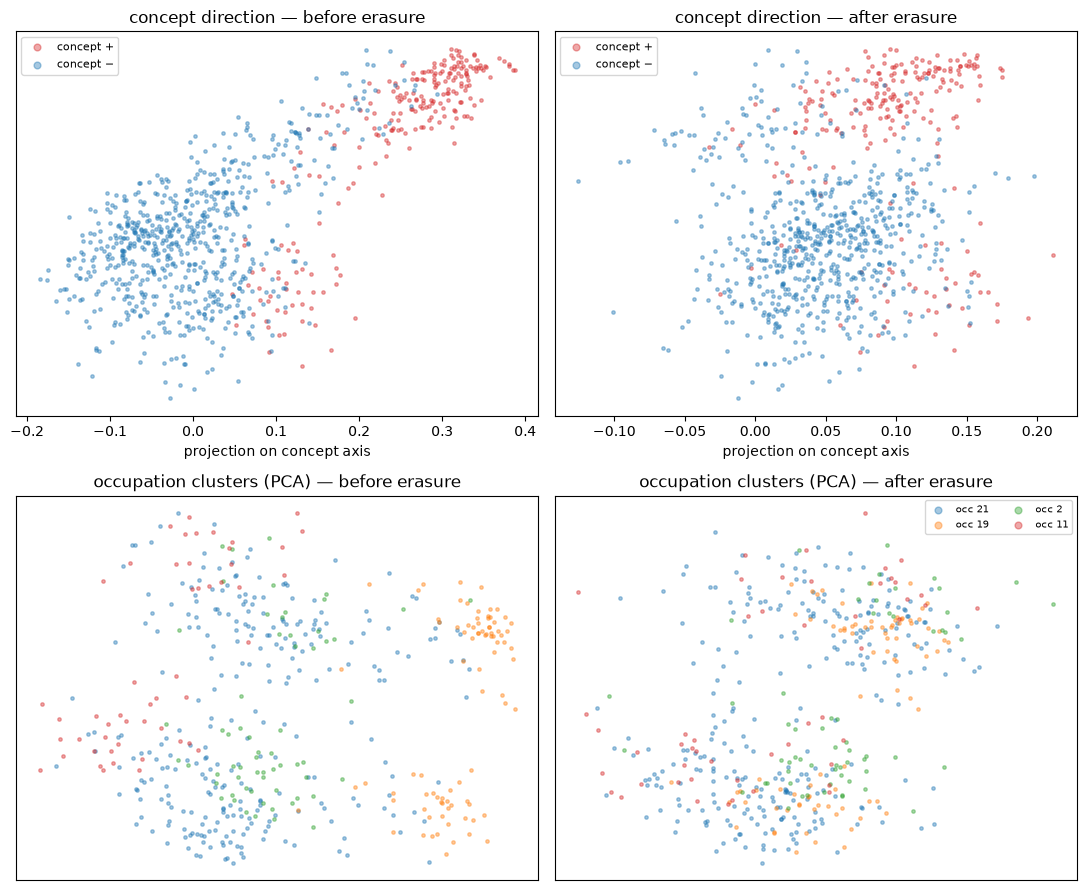

In [5]:
X_before, X_after = X, scrubbed['LEACE']
u = LogisticRegression(max_iter=2000).fit(X_before, concept_1d).coef_[0]; u = u / np.linalg.norm(u)
pc1 = PCA(n_components=1, random_state=SEED).fit_transform(X_before)[:, 0]
pca2 = PCA(n_components=2, random_state=SEED).fit(X_before)
PB, PA = pca2.transform(X_before), pca2.transform(X_after)
vals, counts = np.unique(prof, return_counts=True); top = vals[np.argsort(-counts)[:4]]

fig, ax = plt.subplots(2, 2, figsize=(11, 9))
for col, (M, ttl) in enumerate([(X_before, 'before'), (X_after, 'after')]):
    xg = M @ u
    for cv, lab, c_ in [(1, 'concept +', 'tab:red'), (0, 'concept −', 'tab:blue')]:
        m = concept_1d == cv
        ax[0, col].scatter(xg[m], pc1[m], s=6, alpha=0.4, c=c_, label=lab)
    ax[0, col].set_title(f'concept direction — {ttl} erasure')
    ax[0, col].set_xlabel('projection on concept axis'); ax[0, col].set_yticks([]); ax[0, col].legend(markerscale=2, fontsize=8)
for col, (P, ttl) in enumerate([(PB, 'before'), (PA, 'after')]):
    for t in top:
        m = prof == t
        ax[1, col].scatter(P[m, 0], P[m, 1], s=6, alpha=0.4, label=f'occ {t}')
    ax[1, col].set_title(f'occupation clusters (PCA) — {ttl} erasure')
    ax[1, col].set_xticks([]); ax[1, col].set_yticks([])
ax[1, 1].legend(fontsize=7, markerscale=2, ncol=2)
plt.tight_layout(); plt.show()

## 5. Reading it

- **Gender AUC** falls from ~1.0 toward ~0.5 and the gender axis collapses in the plot — gender is no
  longer linearly recoverable.
- **Occupation accuracy** is largely preserved and the PCA occupation clusters stay put.
- **TPR gap** shrinks — fairer occupation predictions across gender.

LEACE (closed-form, minimal-damage) typically preserves more utility than INLP at equal erasure.
The gains are modest and there is a real fairness–utility tradeoff — gender legitimately correlates
with some occupations. See the README for the math and caveats.

## 6. Cross-erasure validity check

Sanity test of the eraser itself: **erasing a concept should drop *its* accuracy and leave the other concept's accuracy roughly intact.** Here we erase each concept using its **dataset labels** (gender column; occupation `prof` as one-hot for the 28-way class), then measure a gender probe and an occupation probe. No JEV needed — this validates LEACE directly. Expect the diagonal to drop.

In [6]:
from jevu import LeaceEraser

def gender_acc(Xtr_, Xte_):
    c = LogisticRegression(max_iter=2000).fit(Xtr_, gender_raw[tr]); return accuracy_score(gender_raw[te], c.predict(Xte_))
def occ_acc(Xtr_, Xte_):
    c = LogisticRegression(max_iter=3000).fit(Xtr_, prof[tr]); return accuracy_score(prof[te], c.predict(Xte_))

# erasure targets straight from DATASET labels (no JEV here)
classes = np.unique(prof)
occ_onehot = (prof[:, None] == classes[None, :]).astype(float)   # occupation as one-hot (multi-class)
targets = {'erase gender': gender_raw, 'erase occupation': occ_onehot}

rows = [('raw (no erasure)', gender_acc(X[tr], X[te]), occ_acc(X[tr], X[te]))]
for name, z in targets.items():
    er = LeaceEraser().fit(X[tr], z[tr])
    Xtr_d, Xte_d = er.transform(X[tr]), er.transform(X[te])
    rows.append((name, gender_acc(Xtr_d, Xte_d), occ_acc(Xtr_d, Xte_d)))

print(f"{'setting':<20}{'gender acc':>12}{'occupation acc':>16}")
for n, ga, oa in rows:
    print(f"{n:<20}{ga:>12.3f}{oa:>16.3f}")

INFO jevu.erasers: LEACE erased concept (d=1536, k=1)


INFO jevu.erasers: LEACE erased concept (d=1536, k=28)


setting               gender acc  occupation acc
raw (no erasure)           1.000           0.633
erase gender               0.563           0.611
erase occupation           0.978           0.285


## 7. Cross-erasure the LLM + JEV way (label-free)

§6 erased using dataset labels. Here we erase each concept **purely via JEV**: `expand` turns the concept into sub-questions, JEV scores them, and we erase that subspace — then measure both dataset tasks. No ground-truth labels are used for erasing.

**Result (N=900):** with the covering-category expansion prompt and enough questions, label-free erasure matches the label-based ceiling:

| setting | gender acc | occupation acc |
|---|---:|---:|
| raw | 0.996 | 0.648 |
| erase gender (LLM+JEV, 6 q) | **0.515** | 0.589 |
| erase occupation (LLM+JEV, 15 q) | 0.978 | **0.322** |
| erase occupation (labels, §6) | 0.978 | 0.304 |

Each concept's own accuracy collapses while the other survives, and LLM+JEV occupation erasure (0.322) is on par with using the true 28-way labels (0.304). The key is the expansion prompt generating a *covering set* of occupation sub-categories; for a fine-grained identity give it enough questions (`n_questions` ≈ the number of distinct categories). First run calls the LLM + JEV live (keys from `.env`); set `USE_CACHE=True` to make re-runs free.

In [7]:
def gender_acc(Xtr_, Xte_):
    c = LogisticRegression(max_iter=2000).fit(Xtr_, gender_raw[tr]); return accuracy_score(gender_raw[te], c.predict(Xte_))
def occ_acc(Xtr_, Xte_):
    c = LogisticRegression(max_iter=3000).fit(Xtr_, prof[tr]); return accuracy_score(prof[te], c.predict(Xte_))

specs = {
    'erase gender':     dict(concept='gender', n_questions=6),
    'erase occupation': dict(concept='the specific profession or occupation the person has', n_questions=15),
}
rows = [('raw (no erasure)', gender_acc(X[tr], X[te]), occ_acc(X[tr], X[te]))]
for name, spec in specs.items():
    scr = ConceptScrubber(method='leace', expand=True, cache_dir=str(CACHE) if CACHE else None, **spec)
    scr.fit(embeddings=X[tr], texts=[texts[i] for i in tr])   # JEV labels (train) -> fit eraser; no dataset labels
    Xtr_d, Xte_d = scr.transform(X[tr]), scr.transform(X[te])
    print(f'  {name}: {scr.concept_questions_}')
    rows.append((name, gender_acc(Xtr_d, Xte_d), occ_acc(Xtr_d, Xte_d)))

print(f"{'setting':<20}{'gender acc':>12}{'occupation acc':>16}")
for n, ga, oa in rows:
    print(f"{n:<20}{ga:>12.3f}{oa:>16.3f}")

INFO httpx2: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO jevu.concepts: expanded concept 'gender' into 6 questions: ['Does the text refer to a woman?', 'Does the text refer to a man?', 'Does the text mention gendered pronouns or titles?', 'Does the text explicitly identify a non-binary person?', 'Does the text use a feminine name?', 'Does the text use a masculine name?']


INFO jevu.concepts: scoring 630 texts x 6 sub-concepts = 3780 cells (1166 cached, 2614 to fetch)


JEV x6: gender:   0%|          | 0/3780 [00:00<?, ?it/s]

INFO jevu.erasers: LEACE erased concept (d=1536, k=6)


...

INFO jevu.concepts: expanded concept 'the specific profession or occupation the person has' into 15 questions: ['Does the text refer to a healthcare professional?', 'Does the text refer to an educator or academic?', 'Does the text refer to an artist or performer?', 'Does the text refer to a legal professional?', 'Does the text refer to a scientist or researcher?', 'Does the text refer to a writer or journalist?', 'Does the text refer to a musician or composer?', 'Does the text refer to a psychologist or psychiatrist?', 'Does the text refer to an engineer or technical worker?', 'Does the text refer to a business or financial professional?', 'Does the text describe someone in a leadership or managerial role?', 'Does the text refer to a professional in the field of social work or counseling?', 'Does the text refer to a chef or culinary professional?', 'Does the text refer to a medical researcher or clinician?', 'Does the text mention a professional in the technology sector?']


INFO jevu.concepts: scoring 630 texts x 15 sub-concepts = 9450 cells (258 cached, 9192 to fetch)


JEV x15: the specific profession or occ:   0%|          | 0/9450 [00:00<?, ?it/s]

INFO jevu.erasers: LEACE erased concept (d=1536, k=15)


  erase occupation: ['Does the text refer to a healthcare professional?', 'Does the text refer to an educator or academic?', 'Does the text refer to an artist or performer?', 'Does the text refer to a legal professional?', 'Does the text refer to a scientist or researcher?', 'Does the text refer to a writer or journalist?', 'Does the text refer to a musician or composer?', 'Does the text refer to a psychologist or psychiatrist?', 'Does the text refer to an engineer or technical worker?', 'Does the text refer to a business or financial professional?', 'Does the text describe someone in a leadership or managerial role?', 'Does the text refer to a professional in the field of social work or counseling?', 'Does the text refer to a chef or culinary professional?', 'Does the text refer to a medical researcher or clinician?', 'Does the text mention a professional in the technology sector?']
setting               gender acc  occupation acc
raw (no erasure)           1.000           0.633
erase

## 8. `select_k`: keep only a few questions (greedy, logged)

Over-generate a pool for occupation, then let `select_k` **greedily keep the 3 questions that best reconstruct the pool** — a small, reusable eraser. Watch the `INFO jevu.scrubber: greedy select …` lines below for what it picked (also stored in `selected_questions_`). We then erase with just those 3 and check held-out occupation accuracy.

This greedy is **label-free** (reconstructs the pool), so it lands a bit above the supervised best; it's the fast, deployable option.

In [8]:
pool_scrubber = ConceptScrubber(method='leace', expand=True,
    concept='the specific profession or occupation the person has',
    n_questions=15, select_k=3, cache_dir=str(CACHE) if CACHE else None)
pool_scrubber.fit(embeddings=X[tr], texts=[texts[i] for i in tr])
print('selected 3 questions:')
for q in pool_scrubber.selected_questions_: print('   -', q)
Xd = pool_scrubber.transform(X)
def occ(A, B):
    from sklearn.linear_model import LogisticRegression
    return accuracy_score(prof[te], LogisticRegression(max_iter=3000).fit(A, prof[tr]).predict(B))
print(f'occupation acc:  raw {occ(X[tr], X[te]):.3f}  ->  select-3 {occ(Xd[tr], Xd[te]):.3f}')

INFO jevu.concepts: expanded concept 'the specific profession or occupation the person has' into 15 questions: ['Does the text refer to a healthcare professional?', 'Does the text refer to an educator or academic?', 'Does the text refer to an artist or performer?', 'Does the text refer to a legal professional?', 'Does the text refer to a scientist or researcher?', 'Does the text refer to a writer or journalist?', 'Does the text refer to a musician or composer?', 'Does the text refer to a psychologist or psychiatrist?', 'Does the text refer to an engineer or technical worker?', 'Does the text refer to a business or financial professional?', 'Does the text describe someone in a leadership or managerial role?', 'Does the text refer to a professional in the field of social work or counseling?', 'Does the text refer to a chef or culinary professional?', 'Does the text refer to a medical researcher or clinician?', 'Does the text mention a professional in the technology sector?']


INFO jevu.concepts: scoring 630 texts x 15 sub-concepts = 9450 cells (9450 cached, 0 to fetch)


JEV x15: the specific profession or occ:   0%|          | 0/9450 [00:00<?, ?it/s]

INFO jevu.scrubber: greedy select 1/3: 'Does the text refer to a healthcare professional?' (reconstruction residual 24.026)


INFO jevu.scrubber: greedy select 2/3: 'Does the text refer to a scientist or researcher?' (reconstruction residual 20.040)


INFO jevu.scrubber: greedy select 3/3: 'Does the text describe someone in a leadership or managerial role?' (reconstruction residual 18.126)


INFO jevu.scrubber: kept 3/15 questions: ['Does the text refer to a healthcare professional?', 'Does the text refer to a scientist or researcher?', 'Does the text describe someone in a leadership or managerial role?']


INFO jevu.erasers: LEACE erased concept (d=1536, k=3)


selected 3 questions:
   - Does the text refer to a healthcare professional?
   - Does the text refer to a scientist or researcher?
   - Does the text describe someone in a leadership or managerial role?
occupation acc:  raw 0.633  ->  select-3 0.396
